# Notebook 02 — Bases de Pandas
**Auteur** : Louan  
**Objectif** : se familiariser avec Pandas à travers des exercices appliqués à des données financières réelles.

Ce notebook couvre :
- Création et manipulation de Series et DataFrames
- Chargement de données depuis Internet
- Indexation, filtrage, séries temporelles
- Calcul de rendements et de moyennes mobiles
- Visualisation

## Exercice 1 — Création et exploration d'un DataFrame
On crée manuellement un petit DataFrame de prix et de volumes pour se familiariser avec les opérations de base.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.DataFrame(
    {
        'prix': [100, 102, 101, 105, 103, 107, 108, 110, 109, 112],
        'volume': [1000, 1200, 900, 1500, 1100, 1300, 1400, 1600, 1250, 1700]
    },
    index=pd.date_range('2024-01-01', periods=10, freq='D')
)

print("DataFrame complet :")
print(df)

print(f"\nShape : {df.shape}")
print(f"\nDtypes :\n{df.dtypes}")
print(f"\nStatistiques descriptives :\n{df.describe()}")
print(f"\nMoyennes :\n{df.mean()}")

print(f"\nLignes où prix > 105 :")
print(df[df['prix'] > 105])

df['rendement'] = df['prix'].pct_change()

print(f"\nDataFrame avec rendement :")
print(df)

DataFrame complet :
            prix  volume
2024-01-01   100    1000
2024-01-02   102    1200
2024-01-03   101     900
2024-01-04   105    1500
2024-01-05   103    1100
2024-01-06   107    1300
2024-01-07   108    1400
2024-01-08   110    1600
2024-01-09   109    1250
2024-01-10   112    1700

Shape : (10, 2)

Dtypes :
prix      int64
volume    int64
dtype: object

Statistiques descriptives :
             prix      volume
count   10.000000    10.00000
mean   105.700000  1295.00000
std      4.110961   258.68256
min    100.000000   900.00000
25%    102.250000  1125.00000
50%    106.000000  1275.00000
75%    108.750000  1475.00000
max    112.000000  1700.00000

Moyennes :
prix       105.7
volume    1295.0
dtype: float64

Lignes où prix > 105 :
            prix  volume
2024-01-06   107    1300
2024-01-07   108    1400
2024-01-08   110    1600
2024-01-09   109    1250
2024-01-10   112    1700

DataFrame avec rendement :
            prix  volume  rendement
2024-01-01   100    1000        Na

## Exercice 2 — Charger des vraies données de marché depuis Internet

On télécharge l'historique mensuel du S&P 500 directement depuis un dépôt GitHub public. C'est ton premier contact avec des données réelles.

Source : https://github.com/datasets/s-and-p-500 (données mensuelles depuis 1871, basées sur les travaux de Robert Shiller, prix Nobel 2013).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

print("5 premières lignes :")
print(sp500.head())
print(f"\n5 dernières lignes :")
print(sp500.tail())
print(f"\nShape : {sp500.shape}")
print(f"\nDtypes :")
print(sp500.dtypes)
print(f"\nValeurs manquantes par colonne :")
print(sp500.isna().sum())

5 premières lignes :
         Date  SP500  Dividend  Earnings  Consumer Price Index  \
0  1871-01-01   4.44      0.26       0.4                 12.46   
1  1871-02-01   4.50      0.26       0.4                 12.84   
2  1871-03-01   4.61      0.26       0.4                 13.03   
3  1871-04-01   4.74      0.26       0.4                 12.56   
4  1871-05-01   4.86      0.26       0.4                 12.27   

   Long Interest Rate  Real Price  Real Dividend  Real Earnings  PE10  
0                5.32      109.05           6.39           9.82   0.0  
1                5.32      107.25           6.20           9.53   0.0  
2                5.33      108.27           6.11           9.39   0.0  
3                5.33      115.54           6.34           9.75   0.0  
4                5.33      121.22           6.48           9.98   0.0  

5 dernières lignes :
            Date    SP500  Dividend  Earnings  Consumer Price Index  \
1860  2026-01-01  6929.12       0.0       0.0            

## Exercice 3 — Séries temporelles : datetime, index et premier graphe

Le DataFrame chargé a une colonne `Date` lue comme du texte. On va :
1. Garder uniquement `Date` et `SP500`
2. Convertir `Date` en vrai datetime
3. Mettre `Date` en index
4. Calculer les rendements mensuels
5. Tracer la courbe historique du S&P 500

5 premières lignes :
            SP500  rendement
Date                        
1871-01-01   4.44        NaN
1871-02-01   4.50   0.013514
1871-03-01   4.61   0.024444
1871-04-01   4.74   0.028200
1871-05-01   4.86   0.025316

5 dernières lignes :
              SP500  rendement
Date                          
2026-01-01  6929.12   0.011103
2026-02-01  6893.81  -0.005096
2026-03-01  6654.42  -0.034725
2026-04-01  6957.01   0.045472
2026-05-01  7412.55   0.065479

Index : DatetimeIndex(['1871-01-01', '1871-02-01', '1871-03-01', '1871-04-01',
               '1871-05-01', '1871-06-01', '1871-07-01', '1871-08-01',
               '1871-09-01', '1871-10-01',
               ...
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01'],
              dtype='datetime64[us]', name='Date', length=1865, freq=None)

Dtypes :
SP500        float64
rendement    float64
dtype: obje

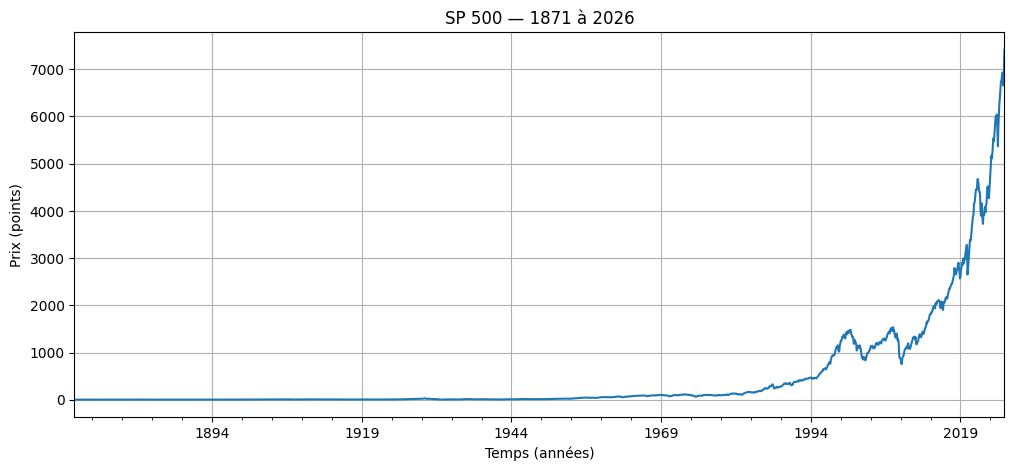

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

# Étape 1 — Garder uniquement Date et SP500
sp = sp500[['Date', 'SP500']].copy()

# Étape 2 — Convertir Date en datetime
sp['Date'] = pd.to_datetime(sp['Date'])

# Étape 3 — Mettre Date en index
sp = sp.set_index('Date')

# Étape 4 — Calculer les rendements mensuels
sp['rendement'] = sp['SP500'].pct_change()

# Étape 5 — Inspection
print("5 premières lignes :")
print(sp.head())
print("\n5 dernières lignes :")
print(sp.tail())
print(f"\nIndex : {sp.index}")
print(f"\nDtypes :")
print(sp.dtypes)

# Étape 6 — Premier graphe
sp['SP500'].plot(figsize=(12, 5), title='SP 500 — 1871 à 2026', grid=True)
plt.ylabel('Prix (points)')
plt.xlabel('Temps (années)')
plt.show()